<a href="https://colab.research.google.com/github/gerald-hlabiso/business-analytics-portfolio/blob/main/projects/cost-sensitive-heart-disease-screening/cost-sensitive-heart-disease-screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost-Sensitive Heart Disease Screening Decision Support

## Project Overview

Heart-disease screening is an asymmetric decision problem. Missing a patient with heart disease may carry a substantially greater cost than referring a patient who ultimately does not have the condition.

This project develops a machine-learning decision-support workflow that compares predictive models, evaluates probability calibration, and selects a classification threshold using the relative costs of false-negative and false-positive decisions.

## Business Question

**How can machine learning support heart-disease screening while making the cost of missed disease cases and unnecessary referrals visible to decision-makers?**

## Decision-Maker

The intended decision-maker is a healthcare screening or clinical-operations team responsible for prioritizing patients for further diagnostic assessment.

The model does not diagnose heart disease. It estimates the likelihood of disease presence using the available dataset and supports referral prioritization.

## Project Objectives

- Use a real public heart-disease dataset rather than synthetic observations
- Examine patient characteristics and target-class distribution
- Compare Logistic Regression, Random Forest, and Gradient Boosting
- Evaluate accuracy, precision, recall, F1, ROC-AUC, and PR-AUC
- Assess the calibration of predicted probabilities
- Select a decision threshold using asymmetric error costs
- Compare default-threshold and cost-sensitive decisions
- Identify influential screening features
- Examine false positives and false negatives
- Test realistic patient-screening scenarios
- Communicate limitations and responsible-use requirements

## Cost Framework

The dataset documentation provides the following relative misclassification costs:

| Actual condition | Predicted absence | Predicted presence |
|---|---:|---:|
| Disease absent | 0 | 1 |
| Disease present | 5 | 0 |

Under this framework:

- A **false positive** has a relative cost of **1**
- A **false negative** has a relative cost of **5**

This makes recall especially important, while still recognizing the operational burden of unnecessary referrals.

## Data Source

The project uses the **Statlog Heart Disease dataset** from the UCI Machine Learning Repository.

- **Observations:** 270
- **Predictors:** 13
- **Target:** Presence or absence of heart disease
- **Missing values:** None
- **Task:** Binary classification

> **Responsible-use statement:** This notebook is an educational decision-support prototype. It is not a medical device, clinical diagnosis, or substitute for professional medical judgment.

In [1]:
# ============================================================
# ENVIRONMENT SETUP AND DATA LOADING
# ============================================================

!pip install -q pandas numpy scikit-learn matplotlib seaborn plotly

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# ============================================================
# LOAD THE UCI STATLOG HEART DATASET
# ============================================================

DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/statlog/heart/heart.dat"
)

column_names = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "serum_cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "maximum_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "major_vessels",
    "thalassemia",
    "heart_disease_original"
]

heart_data = pd.read_csv(
    DATA_URL,
    sep=r"\s+",
    names=column_names
)

# According to the dataset coding:
# 1 = heart disease absent
# 2 = heart disease present
heart_data["heart_disease"] = (
    heart_data["heart_disease_original"]
    .map({
        1: 0,
        2: 1
    })
)

heart_data = heart_data.drop(
    columns=["heart_disease_original"]
)

# ============================================================
# BASIC DATA VALIDATION
# ============================================================

expected_columns = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "serum_cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "maximum_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "major_vessels",
    "thalassemia",
    "heart_disease"
]

if list(heart_data.columns) != expected_columns:
    raise ValueError("Unexpected dataset columns.")

if heart_data["heart_disease"].isna().any():
    raise ValueError(
        "The target variable contains unexpected values."
    )

if not set(heart_data["heart_disease"].unique()).issubset({0, 1}):
    raise ValueError(
        "The target variable was not converted correctly."
    )

duplicate_count = int(
    heart_data.duplicated().sum()
)

missing_value_count = int(
    heart_data.isna().sum().sum()
)

class_counts = (
    heart_data["heart_disease"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    heart_data["heart_disease"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

# ============================================================
# DISPLAY THE VALIDATION SUMMARY
# ============================================================

print("=" * 70)
print("UCI STATLOG HEART DATASET VALIDATION")
print("=" * 70)

print(f"Rows:                 {heart_data.shape[0]}")
print(f"Predictor columns:    {heart_data.shape[1] - 1}")
print(f"Missing values:       {missing_value_count}")
print(f"Duplicate rows:       {duplicate_count}")

print("\nTarget coding")
print("-" * 70)
print("0 = Heart disease absent")
print("1 = Heart disease present")

print("\nTarget distribution")
print("-" * 70)

target_summary = pd.DataFrame({
    "Class": [
        "Disease Absent",
        "Disease Present"
    ],
    "Count": [
        int(class_counts.get(0, 0)),
        int(class_counts.get(1, 0))
    ],
    "Percentage": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

display(
    target_summary.style.format({
        "Percentage": "{:.2f}%"
    })
)

print("\nFirst five observations")
print("-" * 70)

display(heart_data.head())

UCI STATLOG HEART DATASET VALIDATION
Rows:                 270
Predictor columns:    13
Missing values:       0
Duplicate rows:       0

Target coding
----------------------------------------------------------------------
0 = Heart disease absent
1 = Heart disease present

Target distribution
----------------------------------------------------------------------


,Class,Count,Percentage
0,Disease Absent,150,55.56%
1,Disease Present,120,44.44%



First five observations
----------------------------------------------------------------------


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,maximum_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,heart_disease
0,70.0000,1.0000,4.0000,130.0000,322.0000,0.0000,2.0000,109.0000,0.0000,2.4000,2.0000,3.0000,3.0000,1
1,67.0000,0.0000,3.0000,115.0000,564.0000,0.0000,2.0000,160.0000,0.0000,1.6000,2.0000,0.0000,7.0000,0
2,57.0000,1.0000,2.0000,124.0000,261.0000,0.0000,0.0000,141.0000,0.0000,0.3000,1.0000,0.0000,7.0000,1
3,64.0000,1.0000,4.0000,128.0000,263.0000,0.0000,0.0000,105.0000,1.0000,0.2000,2.0000,1.0000,7.0000,0
4,74.0000,0.0000,2.0000,120.0000,269.0000,0.0000,2.0000,121.0000,1.0000,0.2000,1.0000,1.0000,3.0000,0


## Exploratory Data Analysis

This section examines the target balance and compares selected clinical measurements between patients with and without recorded heart disease.

The visualizations describe patterns within this historical dataset. They do not establish causation, clinical thresholds, or medical guidance.

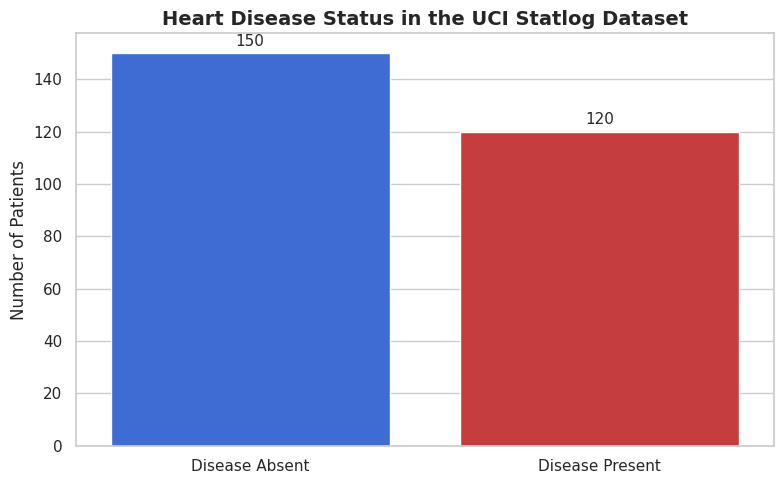

NUMERIC FEATURE SUMMARY BY DISEASE STATUS


age         resting_blood_pressure           \
                   mean  median                   mean   median   
Disease Status                                                    
Disease Absent  52.7100 52.0000               128.8700 130.0000   
Disease Present 56.5900 58.0000               134.4400 130.0000   

                serum_cholesterol          maximum_heart_rate           \
                             mean   median               mean   median   
Disease Status                                                           
Disease Absent           244.2100 236.0000           158.3300 161.0000   
Disease Present          256.4700 255.5000           138.8600 141.5000   

                st_depression         
                         mean median  
Disease Status                        
Disease Absent         0.6200 0.2000  
Disease Present        1.5800 1.4000

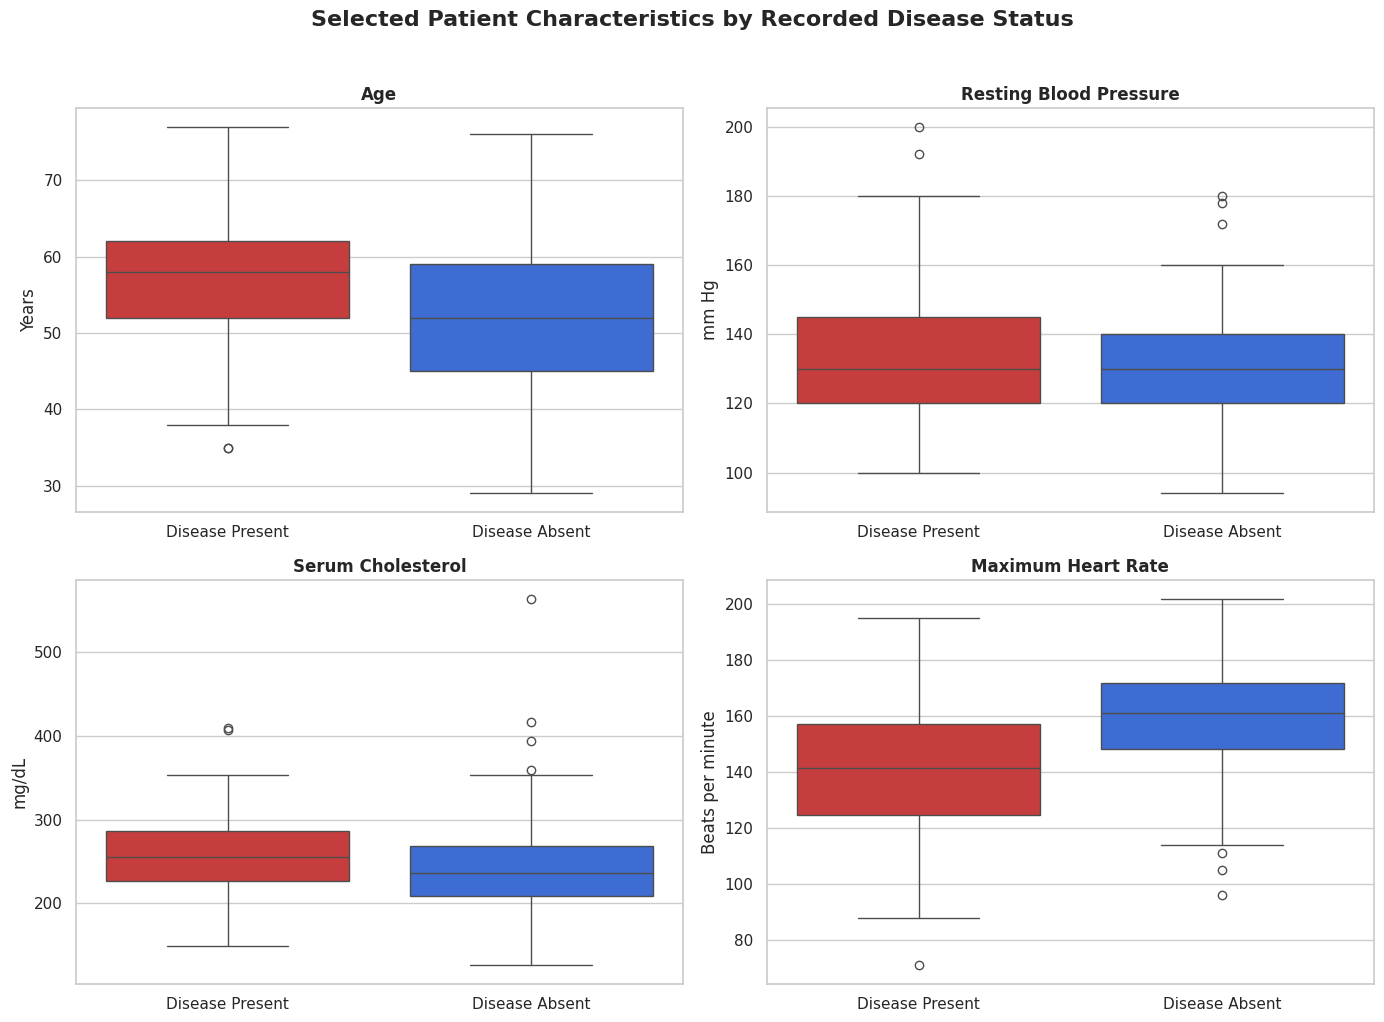

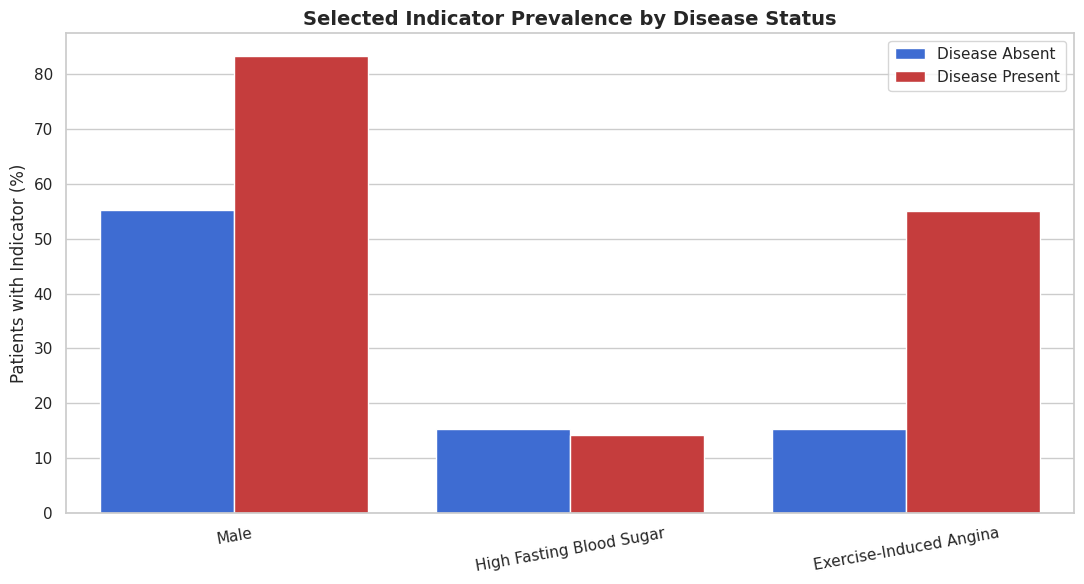

In [2]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

# Create readable outcome labels for charts.
heart_data_eda = heart_data.copy()

heart_data_eda["Disease Status"] = (
    heart_data_eda["heart_disease"]
    .map({
        0: "Disease Absent",
        1: "Disease Present"
    })
)

# ============================================================
# 1. TARGET DISTRIBUTION
# ============================================================

outcome_counts = (
    heart_data_eda["Disease Status"]
    .value_counts()
    .reindex([
        "Disease Absent",
        "Disease Present"
    ])
    .reset_index()
)

outcome_counts.columns = [
    "Disease Status",
    "Patients"
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=outcome_counts,
    x="Disease Status",
    y="Patients",
    palette={
        "Disease Absent": "#2563EB",
        "Disease Present": "#DC2626"
    }
)

plt.title(
    "Heart Disease Status in the UCI Statlog Dataset",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11
    )

plt.tight_layout()
plt.show()

# ============================================================
# 2. NUMERIC FEATURE SUMMARY BY OUTCOME
# ============================================================

numeric_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol",
    "maximum_heart_rate",
    "st_depression"
]

numeric_summary = (
    heart_data_eda
    .groupby("Disease Status")[numeric_features]
    .agg(["mean", "median"])
    .round(2)
)

print("=" * 70)
print("NUMERIC FEATURE SUMMARY BY DISEASE STATUS")
print("=" * 70)

display(numeric_summary)

# ============================================================
# 3. DISTRIBUTIONS OF SELECTED CLINICAL MEASUREMENTS
# ============================================================

plot_features = [
    (
        "age",
        "Age",
        "Years"
    ),
    (
        "resting_blood_pressure",
        "Resting Blood Pressure",
        "mm Hg"
    ),
    (
        "serum_cholesterol",
        "Serum Cholesterol",
        "mg/dL"
    ),
    (
        "maximum_heart_rate",
        "Maximum Heart Rate",
        "Beats per minute"
    )
]

figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for axis, (
    feature,
    title,
    y_label
) in zip(axes.flatten(), plot_features):

    sns.boxplot(
        data=heart_data_eda,
        x="Disease Status",
        y=feature,
        hue="Disease Status",
        palette={
            "Disease Absent": "#2563EB",
            "Disease Present": "#DC2626"
        },
        legend=False,
        ax=axis
    )

    axis.set_title(
        title,
        fontweight="bold"
    )
    axis.set_xlabel("")
    axis.set_ylabel(y_label)

plt.suptitle(
    "Selected Patient Characteristics by Recorded Disease Status",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# 4. BINARY RISK-INDICATOR PREVALENCE
# ============================================================

binary_features = {
    "sex": "Male",
    "fasting_blood_sugar": "High Fasting Blood Sugar",
    "exercise_induced_angina": "Exercise-Induced Angina"
}

binary_prevalence_records = []

for feature, readable_name in binary_features.items():

    grouped_rates = (
        heart_data_eda
        .groupby("Disease Status")[feature]
        .mean()
        .mul(100)
    )

    for disease_status, prevalence in grouped_rates.items():
        binary_prevalence_records.append({
            "Indicator": readable_name,
            "Disease Status": disease_status,
            "Prevalence": prevalence
        })

binary_prevalence_df = pd.DataFrame(
    binary_prevalence_records
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=binary_prevalence_df,
    x="Indicator",
    y="Prevalence",
    hue="Disease Status",
    palette={
        "Disease Absent": "#2563EB",
        "Disease Present": "#DC2626"
    }
)

plt.title(
    "Selected Indicator Prevalence by Disease Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Patients with Indicator (%)")
plt.xticks(rotation=10)
plt.legend(title="")
plt.tight_layout()
plt.show()

## Data Preparation and Modeling Design

The dataset is divided into:

- **80% development data:** Used for preprocessing, model comparison, probability calibration, and threshold selection
- **20% held-out test data:** Used once for final evaluation

Categorical codes are one-hot encoded rather than treated as continuous quantities. Numeric variables are standardized for models that depend on feature scale.

All preprocessing is placed inside each model pipeline so that transformations are learned only from the relevant training folds, reducing data leakage.

In [3]:
# ============================================================
# DATA PREPARATION AND MODEL PIPELINES
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# ============================================================
# 1. DEFINE PREDICTORS AND TARGET
# ============================================================

X = heart_data.drop(
    columns=["heart_disease"]
)

y = heart_data["heart_disease"].astype(int)

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
    "st_slope",
    "major_vessels",
    "thalassemia"
]

numeric_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol",
    "maximum_heart_rate",
    "st_depression"
]

# Confirm that every predictor is assigned exactly once.
assigned_features = (
    categorical_features +
    numeric_features
)

if set(assigned_features) != set(X.columns):
    raise ValueError(
        "The preprocessing feature lists do not match the dataset."
    )

# ============================================================
# 2. CREATE THE HELD-OUT TEST SET
# ============================================================

X_development, X_test, y_development, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )
)

# ============================================================
# 3. BUILD THE PREPROCESSOR
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

# ============================================================
# 4. DEFINE THE MODEL CANDIDATES
# ============================================================

model_candidates = {
    "Dummy Baseline": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                DummyClassifier(
                    strategy="prior",
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Logistic Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=200,
                    learning_rate=0.03,
                    max_depth=2,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
}

# ============================================================
# 5. DEFINE REPEATED STRATIFIED CROSS-VALIDATION
# ============================================================

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

# ============================================================
# 6. DISPLAY THE MODELING SPLIT
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": [
        "Development",
        "Held-Out Test"
    ],
    "Rows": [
        len(X_development),
        len(X_test)
    ],
    "Disease Present": [
        int(y_development.sum()),
        int(y_test.sum())
    ],
    "Disease Absent": [
        int((y_development == 0).sum()),
        int((y_test == 0).sum())
    ]
})

print("=" * 70)
print("MODELING DESIGN")
print("=" * 70)

print(
    "Development data are used for model comparison and "
    "threshold selection."
)

print(
    "The held-out test set will not be used until final evaluation."
)

display(split_summary)

print("\nModels prepared:")
for model_name in model_candidates:
    print(f"- {model_name}")

MODELING DESIGN
Development data are used for model comparison and threshold selection.
The held-out test set will not be used until final evaluation.


,Dataset,Rows,Disease Present,Disease Absent
0,Development,216,96,120
1,Held-Out Test,54,24,30



Models prepared:
- Dummy Baseline
- Logistic Regression
- Random Forest
- Gradient Boosting


## Repeated Cross-Validation Model Comparison

Because the dataset is small, a single training-validation split could produce an unstable model ranking. Each candidate is therefore evaluated with five-fold stratified cross-validation repeated five times.

The comparison includes discrimination, minority-class performance, and probability quality. The dummy baseline shows how much value the trained models add beyond using the class prevalence alone.

Evaluating Dummy Baseline...
Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...

REPEATED CROSS-VALIDATION RESULTS


,Model,Accuracy Mean,Accuracy SD,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,PR-AUC Mean,Brier Score Mean
0,Logistic Regression,0.831,0.058,0.818,0.812,0.808,0.908,0.909,0.123
1,Random Forest,0.827,0.070,0.821,0.796,0.802,0.914,0.916,0.124
2,Gradient Boosting,0.810,0.069,0.806,0.771,0.782,0.888,0.884,0.135
3,Dummy Baseline,0.556,0.005,0.000,0.000,0.000,0.500,0.444,0.247


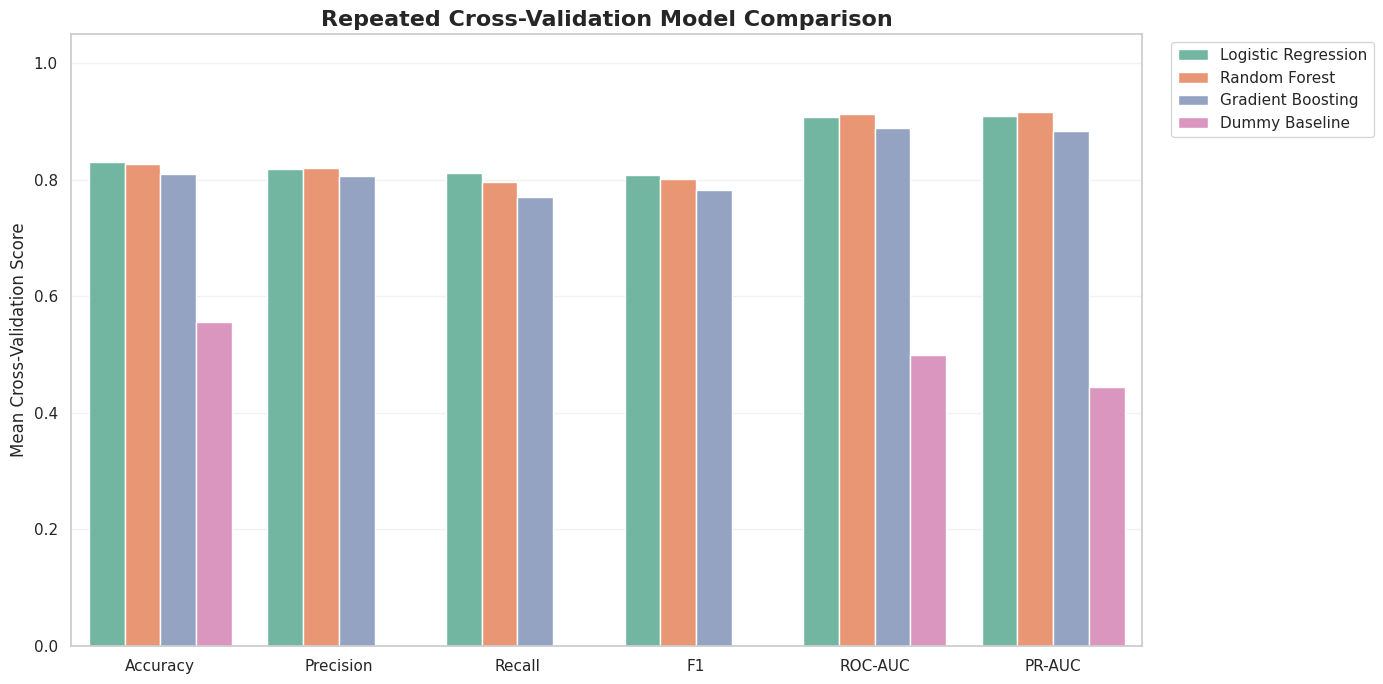

In [4]:
# ============================================================
# REPEATED CROSS-VALIDATION MODEL COMPARISON
# ============================================================

from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

# Define scoring metrics.
scoring_metrics = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc",

    "average_precision": "average_precision",

    "neg_brier_score": "neg_brier_score"
}

cross_validation_records = []

raw_cv_results = {}

# Evaluate every model using the same repeated folds.
for model_name, model_pipeline in model_candidates.items():

    print(f"Evaluating {model_name}...")

    model_cv_results = cross_validate(
        estimator=model_pipeline,
        X=X_development,
        y=y_development,
        cv=repeated_cv,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False
    )

    raw_cv_results[model_name] = model_cv_results

    cross_validation_records.append({
        "Model": model_name,

        "Accuracy Mean":
            model_cv_results["test_accuracy"].mean(),

        "Accuracy SD":
            model_cv_results["test_accuracy"].std(),

        "Precision Mean":
            model_cv_results["test_precision"].mean(),

        "Recall Mean":
            model_cv_results["test_recall"].mean(),

        "F1 Mean":
            model_cv_results["test_f1"].mean(),

        "ROC-AUC Mean":
            model_cv_results["test_roc_auc"].mean(),

        "PR-AUC Mean":
            model_cv_results[
                "test_average_precision"
            ].mean(),

        "Brier Score Mean":
            -model_cv_results[
                "test_neg_brier_score"
            ].mean()
    })

# Create the comparison table.
cv_results_df = pd.DataFrame(
    cross_validation_records
)

cv_results_df = cv_results_df.sort_values(
    by=[
        "Recall Mean",
        "PR-AUC Mean"
    ],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("REPEATED CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.style.format({
        "Accuracy Mean": "{:.3f}",
        "Accuracy SD": "{:.3f}",
        "Precision Mean": "{:.3f}",
        "Recall Mean": "{:.3f}",
        "F1 Mean": "{:.3f}",
        "ROC-AUC Mean": "{:.3f}",
        "PR-AUC Mean": "{:.3f}",
        "Brier Score Mean": "{:.3f}"
    })
)

# ============================================================
# VISUALIZE THE MODEL COMPARISON
# ============================================================

plot_metrics = [
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean",
    "ROC-AUC Mean",
    "PR-AUC Mean"
]

plot_data = cv_results_df.melt(
    id_vars="Model",
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score"
)

plot_data["Metric"] = (
    plot_data["Metric"]
    .str.replace(" Mean", "", regex=False)
    .str.replace("PR-AUC", "PR-AUC", regex=False)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title(
    "Repeated Cross-Validation Model Comparison",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1.05)
plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Probability Calibration and Cost-Sensitive Threshold Selection

Logistic Regression is selected for the screening workflow because it produced the strongest cross-validated recall and F1 score while retaining interpretable model structure.

Probability calibration is evaluated because a screening probability should reflect observed outcome frequency as closely as possible. Out-of-fold predictions are used so that each development observation is scored by a model that was not trained on that observation.

The decision threshold is then selected using the documented relative costs:

- False positive cost: 1
- False negative cost: 5

The held-out test set remains untouched during calibration and threshold selection.

OUT-OF-FOLD PROBABILITY CALIBRATION


,Probability Model,Out-of-Fold Brier Score
0,Uncalibrated Logistic Regression,0.1238
1,Sigmoid-Calibrated Logistic Regression,0.1224


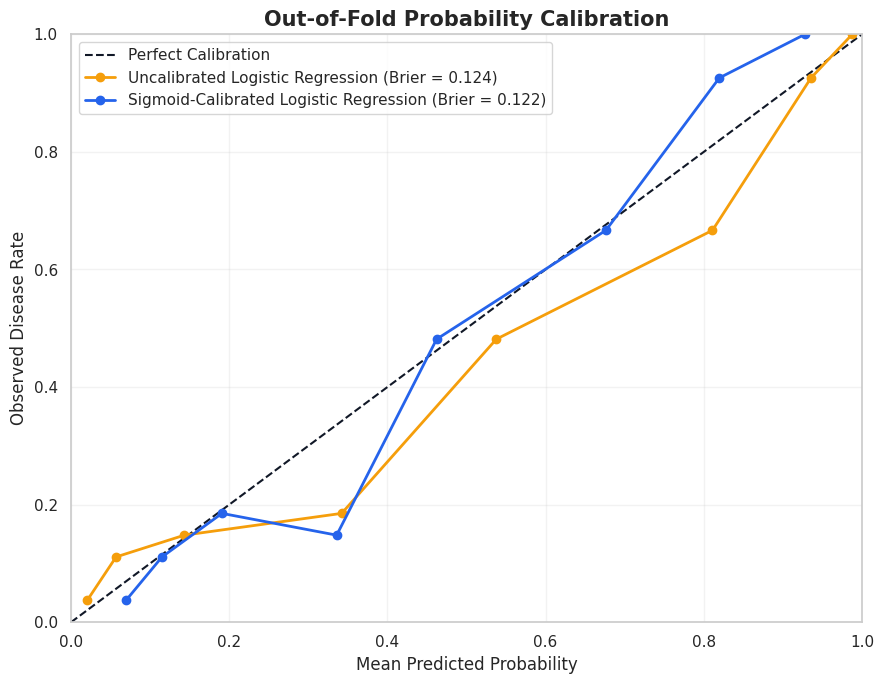

Probability model selected for threshold analysis: Sigmoid-Calibrated Logistic Regression

COST-SENSITIVE THRESHOLD SELECTION
Selected probability model: Sigmoid-Calibrated Logistic Regression
Selected cost-sensitive threshold: 0.36
Minimum development cost: 79


,Decision Rule,Threshold,Precision,Recall,F1,False Positives,False Negatives,Total Relative Cost
0,Default Threshold,0.50,0.837,0.750,0.791,14,24,134
1,Minimum-Cost Threshold,0.36,0.748,0.896,0.815,29,10,79


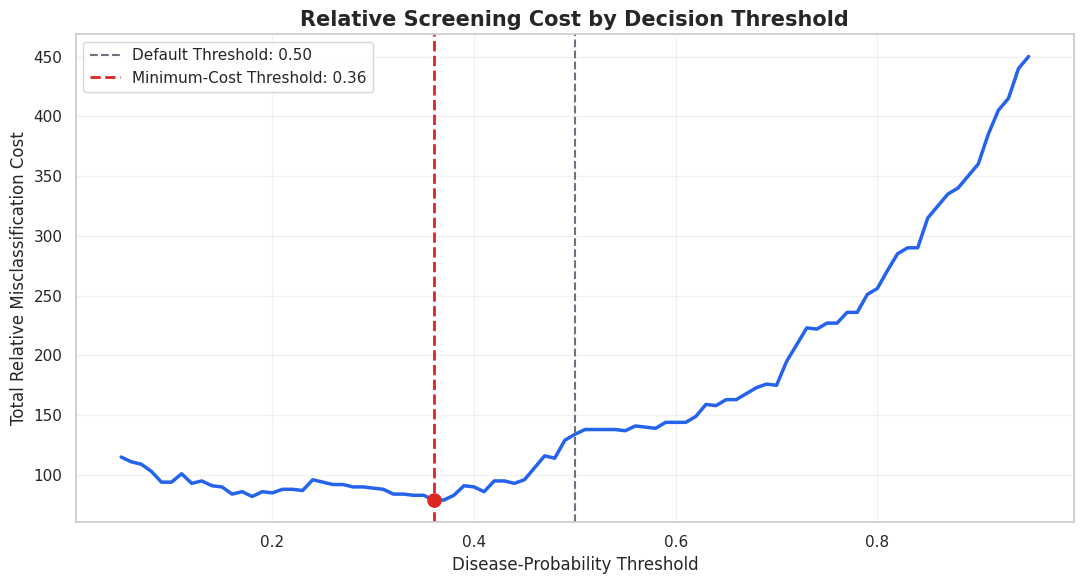

In [5]:
# ============================================================
# PROBABILITY CALIBRATION AND COST-SENSITIVE THRESHOLD SELECTION
# ============================================================

from sklearn.base import clone

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. SELECT THE DEVELOPMENT MODEL
# ============================================================

selected_base_model = clone(
    model_candidates["Logistic Regression"]
)

# Sigmoid calibration is generally more stable than isotonic
# calibration for a small dataset.
calibrated_logistic_model = CalibratedClassifierCV(
    estimator=clone(selected_base_model),
    method="sigmoid",
    cv=5
)

# Use one non-repeated stratified partition for out-of-fold
# probability generation.
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ============================================================
# 2. GENERATE OUT-OF-FOLD PROBABILITIES
# ============================================================

uncalibrated_oof_probabilities = cross_val_predict(
    estimator=selected_base_model,
    X=X_development,
    y=y_development,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

calibrated_oof_probabilities = cross_val_predict(
    estimator=calibrated_logistic_model,
    X=X_development,
    y=y_development,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# ============================================================
# 3. COMPARE BRIER SCORES
# ============================================================

uncalibrated_brier = brier_score_loss(
    y_development,
    uncalibrated_oof_probabilities
)

calibrated_brier = brier_score_loss(
    y_development,
    calibrated_oof_probabilities
)

calibration_comparison = pd.DataFrame({
    "Probability Model": [
        "Uncalibrated Logistic Regression",
        "Sigmoid-Calibrated Logistic Regression"
    ],
    "Out-of-Fold Brier Score": [
        uncalibrated_brier,
        calibrated_brier
    ]
})

print("=" * 72)
print("OUT-OF-FOLD PROBABILITY CALIBRATION")
print("=" * 72)

display(
    calibration_comparison.style.format({
        "Out-of-Fold Brier Score": "{:.4f}"
    })
)

# ============================================================
# 4. CREATE THE CALIBRATION CURVE
# ============================================================

uncalibrated_fraction_positive, uncalibrated_mean_probability = (
    calibration_curve(
        y_development,
        uncalibrated_oof_probabilities,
        n_bins=8,
        strategy="quantile"
    )
)

calibrated_fraction_positive, calibrated_mean_probability = (
    calibration_curve(
        y_development,
        calibrated_oof_probabilities,
        n_bins=8,
        strategy="quantile"
    )
)

plt.figure(figsize=(9, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#111827",
    label="Perfect Calibration"
)

plt.plot(
    uncalibrated_mean_probability,
    uncalibrated_fraction_positive,
    marker="o",
    linewidth=2,
    color="#F59E0B",
    label=(
        "Uncalibrated Logistic Regression "
        f"(Brier = {uncalibrated_brier:.3f})"
    )
)

plt.plot(
    calibrated_mean_probability,
    calibrated_fraction_positive,
    marker="o",
    linewidth=2,
    color="#2563EB",
    label=(
        "Sigmoid-Calibrated Logistic Regression "
        f"(Brier = {calibrated_brier:.3f})"
    )
)

plt.title(
    "Out-of-Fold Probability Calibration",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Disease Rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ============================================================
# 5. SELECT WHICH PROBABILITIES TO USE
# ============================================================

if calibrated_brier < uncalibrated_brier:
    threshold_probabilities = calibrated_oof_probabilities
    probability_model_name = (
        "Sigmoid-Calibrated Logistic Regression"
    )
    final_model_template = clone(
        calibrated_logistic_model
    )
else:
    threshold_probabilities = uncalibrated_oof_probabilities
    probability_model_name = (
        "Uncalibrated Logistic Regression"
    )
    final_model_template = clone(
        selected_base_model
    )

print(
    "Probability model selected for threshold analysis:",
    probability_model_name
)

# ============================================================
# 6. EVALUATE COST ACROSS CANDIDATE THRESHOLDS
# ============================================================

FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 5

threshold_records = []

for threshold in np.arange(0.05, 0.96, 0.01):

    predictions = (
        threshold_probabilities >= threshold
    ).astype(int)

    false_positives = int(
        (
            (predictions == 1) &
            (y_development.to_numpy() == 0)
        ).sum()
    )

    false_negatives = int(
        (
            (predictions == 0) &
            (y_development.to_numpy() == 1)
        ).sum()
    )

    total_cost = (
        FALSE_POSITIVE_COST * false_positives +
        FALSE_NEGATIVE_COST * false_negatives
    )

    threshold_records.append({
        "Threshold": round(float(threshold), 2),

        "Precision": precision_score(
            y_development,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_development,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_development,
            predictions,
            zero_division=0
        ),

        "False Positives": false_positives,
        "False Negatives": false_negatives,
        "Total Relative Cost": total_cost
    })

threshold_results_df = pd.DataFrame(
    threshold_records
)

# ============================================================
# 7. CHOOSE THE MINIMUM-COST THRESHOLD
# ============================================================

minimum_cost = (
    threshold_results_df["Total Relative Cost"]
    .min()
)

minimum_cost_candidates = threshold_results_df[
    threshold_results_df["Total Relative Cost"] ==
    minimum_cost
].copy()

# Resolve any tied costs by selecting the threshold with the
# highest recall, then the highest precision.
minimum_cost_candidates = (
    minimum_cost_candidates
    .sort_values(
        by=[
            "Recall",
            "Precision",
            "Threshold"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

selected_threshold_row = (
    minimum_cost_candidates.iloc[0]
)

selected_threshold = float(
    selected_threshold_row["Threshold"]
)

# Calculate the result at the default threshold for comparison.
default_threshold_row = (
    threshold_results_df[
        np.isclose(
            threshold_results_df["Threshold"],
            0.50
        )
    ]
    .iloc[0]
)

threshold_summary = pd.DataFrame([
    {
        "Decision Rule": "Default Threshold",
        **default_threshold_row.to_dict()
    },
    {
        "Decision Rule": "Minimum-Cost Threshold",
        **selected_threshold_row.to_dict()
    }
])

print("\n" + "=" * 72)
print("COST-SENSITIVE THRESHOLD SELECTION")
print("=" * 72)

print(
    f"Selected probability model: {probability_model_name}"
)

print(
    f"Selected cost-sensitive threshold: "
    f"{selected_threshold:.2f}"
)

print(
    f"Minimum development cost: "
    f"{minimum_cost:.0f}"
)

display(
    threshold_summary[
        [
            "Decision Rule",
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "False Positives",
            "False Negatives",
            "Total Relative Cost"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "False Positives": "{:.0f}",
        "False Negatives": "{:.0f}",
        "Total Relative Cost": "{:.0f}"
    })
)

# ============================================================
# 8. VISUALIZE THE COST CURVE
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Total Relative Cost"],
    color="#2563EB",
    linewidth=2.5
)

plt.axvline(
    0.50,
    color="#6B7280",
    linestyle="--",
    linewidth=1.5,
    label="Default Threshold: 0.50"
)

plt.axvline(
    selected_threshold,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=(
        "Minimum-Cost Threshold: "
        f"{selected_threshold:.2f}"
    )
)

plt.scatter(
    selected_threshold,
    minimum_cost,
    color="#DC2626",
    s=90,
    zorder=5
)

plt.title(
    "Relative Screening Cost by Decision Threshold",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Disease-Probability Threshold")
plt.ylabel("Total Relative Misclassification Cost")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Final Held-Out Test Evaluation

The selected probability model is fitted to all development observations and evaluated once on the untouched test set.

Two decision rules are compared:

1. **Default threshold of 0.50**
2. **Cost-sensitive threshold of 0.36**, selected using out-of-fold development predictions

This comparison measures whether the development-stage cost reduction generalizes to previously unseen patients.

FINAL HELD-OUT TEST RESULTS
ROC-AUC:                       0.908
PR-AUC:                        0.866
Brier Score:                   0.114
Default threshold cost:        15
Cost-sensitive threshold cost: 17
Relative cost reduction:       -13.3%


,Decision Rule,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,False Positives,False Negatives,Total Relative Cost
0,Default Threshold,0.50,0.870,0.875,0.815,0.917,0.833,0.863,5,2,15
1,Cost-Sensitive Threshold,0.36,0.833,0.842,0.759,0.917,0.767,0.830,7,2,17


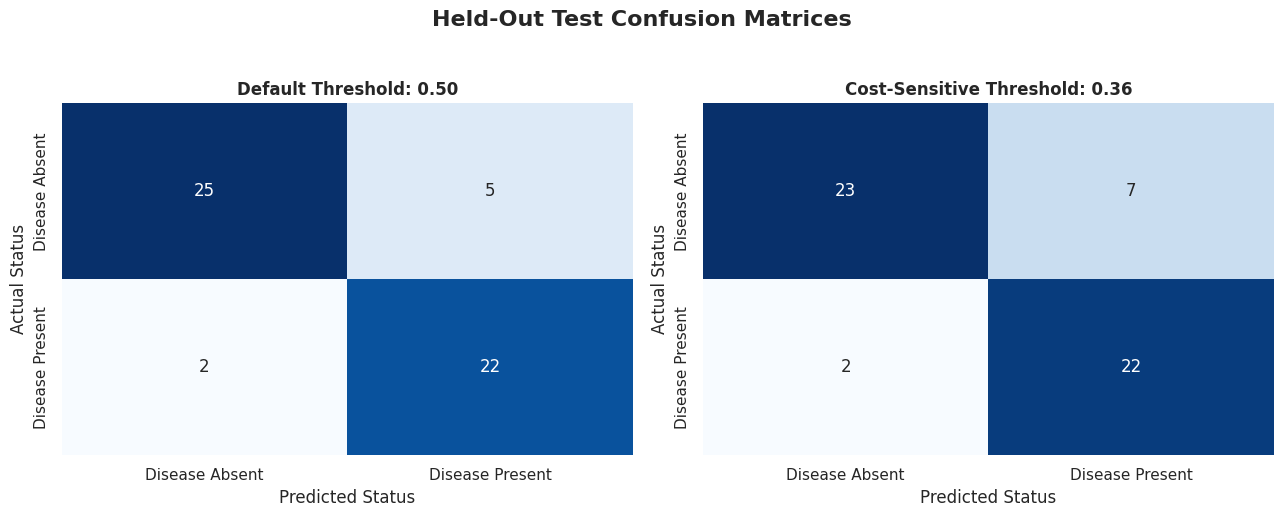

In [6]:
# ============================================================
# FINAL HELD-OUT TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

# ============================================================
# 1. FIT THE SELECTED MODEL TO ALL DEVELOPMENT DATA
# ============================================================

final_model = clone(
    final_model_template
)

final_model.fit(
    X_development,
    y_development
)

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

# ============================================================
# 2. EVALUATION FUNCTION
# ============================================================

def evaluate_decision_threshold(
    y_true,
    probabilities,
    threshold,
    decision_rule
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_negatives, false_positives, false_negatives, true_positives = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()
    )

    total_relative_cost = (
        FALSE_POSITIVE_COST * false_positives +
        FALSE_NEGATIVE_COST * false_negatives
    )

    specificity = (
        true_negatives /
        (true_negatives + false_positives)
        if (true_negatives + false_positives) > 0
        else 0
    )

    return {
        "Decision Rule": decision_rule,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "True Negatives": int(true_negatives),
        "False Positives": int(false_positives),
        "False Negatives": int(false_negatives),
        "True Positives": int(true_positives),
        "Total Relative Cost": int(total_relative_cost),
        "Predictions": predictions
    }

# ============================================================
# 3. COMPARE DEFAULT AND COST-SENSITIVE DECISIONS
# ============================================================

default_test_result = evaluate_decision_threshold(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=0.50,
    decision_rule="Default Threshold"
)

cost_sensitive_test_result = evaluate_decision_threshold(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=selected_threshold,
    decision_rule="Cost-Sensitive Threshold"
)

test_results_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "Predictions"
    }
    for result in [
        default_test_result,
        cost_sensitive_test_result
    ]
])

# ============================================================
# 4. THRESHOLD-INDEPENDENT TEST METRICS
# ============================================================

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

test_brier_score = brier_score_loss(
    y_test,
    test_probabilities
)

default_test_cost = int(
    default_test_result["Total Relative Cost"]
)

cost_sensitive_test_cost = int(
    cost_sensitive_test_result[
        "Total Relative Cost"
    ]
)

test_cost_reduction = (
    (
        default_test_cost -
        cost_sensitive_test_cost
    ) /
    default_test_cost
    if default_test_cost > 0
    else 0
)

print("=" * 75)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 75)

print(f"ROC-AUC:                       {test_roc_auc:.3f}")
print(f"PR-AUC:                        {test_pr_auc:.3f}")
print(f"Brier Score:                   {test_brier_score:.3f}")
print(f"Default threshold cost:        {default_test_cost}")
print(f"Cost-sensitive threshold cost: {cost_sensitive_test_cost}")
print(f"Relative cost reduction:       {test_cost_reduction:.1%}")

display_columns = [
    "Decision Rule",
    "Threshold",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "False Positives",
    "False Negatives",
    "Total Relative Cost"
]

display(
    test_results_df[
        display_columns
    ].style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.3f}",
        "Balanced Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "Specificity": "{:.3f}",
        "F1": "{:.3f}",
        "False Positives": "{:.0f}",
        "False Negatives": "{:.0f}",
        "Total Relative Cost": "{:.0f}"
    })
)

# ============================================================
# 5. CONFUSION-MATRIX COMPARISON
# ============================================================

default_confusion_matrix = confusion_matrix(
    y_test,
    default_test_result["Predictions"],
    labels=[0, 1]
)

cost_sensitive_confusion_matrix = confusion_matrix(
    y_test,
    cost_sensitive_test_result["Predictions"],
    labels=[0, 1]
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

confusion_matrices = [
    (
        default_confusion_matrix,
        "Default Threshold: 0.50"
    ),
    (
        cost_sensitive_confusion_matrix,
        (
            "Cost-Sensitive Threshold: "
            f"{selected_threshold:.2f}"
        )
    )
]

for axis, (
    matrix,
    title
) in zip(axes, confusion_matrices):

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[
            "Disease Absent",
            "Disease Present"
        ],
        yticklabels=[
            "Disease Absent",
            "Disease Present"
        ],
        ax=axis
    )

    axis.set_title(
        title,
        fontweight="bold"
    )
    axis.set_xlabel("Predicted Status")
    axis.set_ylabel("Actual Status")

plt.suptitle(
    "Held-Out Test Confusion Matrices",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

## Generalization Finding and Uncertainty

The cost-sensitive threshold reduced out-of-fold development cost, but this improvement did not generalize to the held-out test set.

Both decision rules detected 22 of the 24 disease-present test cases. Lowering the threshold from 0.50 to 0.36 created two additional false-positive referrals without reducing false negatives.

This result demonstrates an important model-risk principle: threshold optimization can overfit when the available sample is small. The 0.36 threshold should not be recommended for operational use without additional external validation.

Bootstrap confidence intervals are calculated to show the uncertainty surrounding the default-threshold test results.

DEFAULT-THRESHOLD BOOTSTRAP CONFIDENCE INTERVALS
Successful bootstrap samples: 2,000


,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Accuracy,0.870,0.778,0.944
1,Precision,0.815,0.667,0.957
2,Recall,0.917,0.792,1.000
3,F1,0.863,0.755,0.949
4,ROC-AUC,0.908,0.815,0.981
5,PR-AUC,0.866,0.717,0.979
6,Brier Score,0.114,0.069,0.167
7,Relative Cost,15.000,3.000,30.025


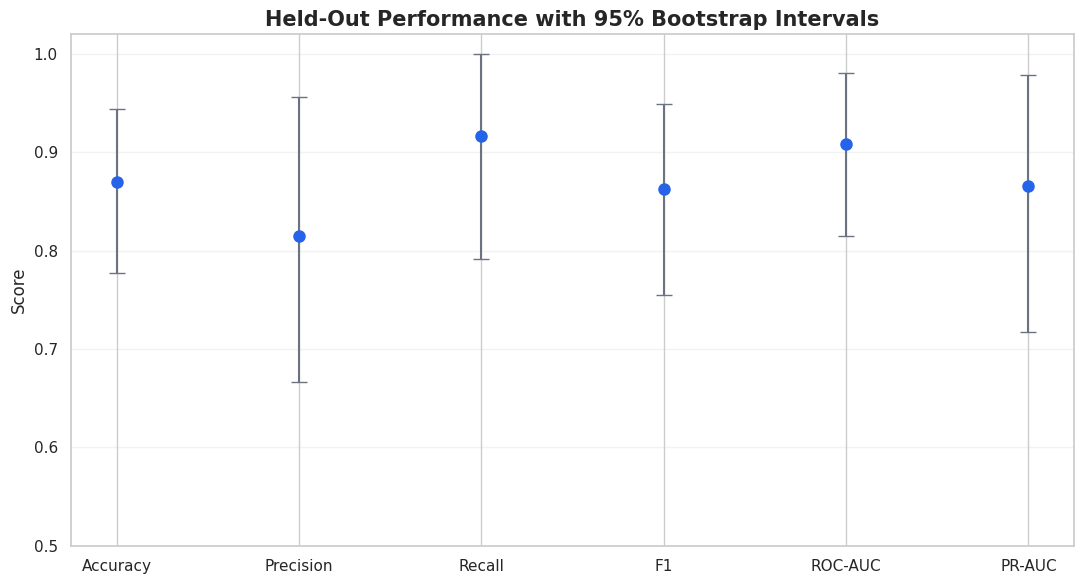

In [7]:
# ============================================================
# BOOTSTRAP UNCERTAINTY ANALYSIS
# ============================================================

BOOTSTRAP_ITERATIONS = 2000
bootstrap_random_generator = np.random.default_rng(
    RANDOM_STATE
)

y_test_array = y_test.to_numpy()

default_test_predictions = (
    test_probabilities >= 0.50
).astype(int)

bootstrap_records = []

for iteration in range(BOOTSTRAP_ITERATIONS):

    sample_indices = bootstrap_random_generator.choice(
        len(y_test_array),
        size=len(y_test_array),
        replace=True
    )

    bootstrap_y = y_test_array[
        sample_indices
    ]

    bootstrap_probabilities = test_probabilities[
        sample_indices
    ]

    bootstrap_predictions = default_test_predictions[
        sample_indices
    ]

    # ROC-AUC requires both classes in the resampled data.
    if len(np.unique(bootstrap_y)) < 2:
        continue

    bootstrap_matrix = confusion_matrix(
        bootstrap_y,
        bootstrap_predictions,
        labels=[0, 1]
    )

    (
        bootstrap_true_negatives,
        bootstrap_false_positives,
        bootstrap_false_negatives,
        bootstrap_true_positives
    ) = bootstrap_matrix.ravel()

    bootstrap_cost = (
        FALSE_POSITIVE_COST *
        bootstrap_false_positives
        +
        FALSE_NEGATIVE_COST *
        bootstrap_false_negatives
    )

    bootstrap_records.append({
        "Accuracy": accuracy_score(
            bootstrap_y,
            bootstrap_predictions
        ),

        "Precision": precision_score(
            bootstrap_y,
            bootstrap_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            bootstrap_y,
            bootstrap_predictions,
            zero_division=0
        ),

        "F1": f1_score(
            bootstrap_y,
            bootstrap_predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            bootstrap_y,
            bootstrap_probabilities
        ),

        "PR-AUC": average_precision_score(
            bootstrap_y,
            bootstrap_probabilities
        ),

        "Brier Score": brier_score_loss(
            bootstrap_y,
            bootstrap_probabilities
        ),

        "Relative Cost": bootstrap_cost
    })

bootstrap_results_df = pd.DataFrame(
    bootstrap_records
)

confidence_interval_records = []

point_estimates = {
    "Accuracy": default_test_result["Accuracy"],
    "Precision": default_test_result["Precision"],
    "Recall": default_test_result["Recall"],
    "F1": default_test_result["F1"],
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
    "Brier Score": test_brier_score,
    "Relative Cost": default_test_cost
}

for metric, point_estimate in point_estimates.items():

    lower_bound = bootstrap_results_df[
        metric
    ].quantile(0.025)

    upper_bound = bootstrap_results_df[
        metric
    ].quantile(0.975)

    confidence_interval_records.append({
        "Metric": metric,
        "Point Estimate": point_estimate,
        "95% CI Lower": lower_bound,
        "95% CI Upper": upper_bound
    })

confidence_intervals_df = pd.DataFrame(
    confidence_interval_records
)

print("=" * 72)
print("DEFAULT-THRESHOLD BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 72)

print(
    f"Successful bootstrap samples: "
    f"{len(bootstrap_results_df):,}"
)

display(
    confidence_intervals_df.style.format({
        "Point Estimate": "{:.3f}",
        "95% CI Lower": "{:.3f}",
        "95% CI Upper": "{:.3f}"
    })
)

# Visualize uncertainty for the primary classification metrics.
classification_interval_df = (
    confidence_intervals_df[
        confidence_intervals_df["Metric"].isin([
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ])
    ]
    .copy()
)

classification_interval_df["Lower Error"] = (
    classification_interval_df["Point Estimate"] -
    classification_interval_df["95% CI Lower"]
)

classification_interval_df["Upper Error"] = (
    classification_interval_df["95% CI Upper"] -
    classification_interval_df["Point Estimate"]
)

plt.figure(figsize=(11, 6))

plt.errorbar(
    x=classification_interval_df["Metric"],
    y=classification_interval_df["Point Estimate"],
    yerr=[
        classification_interval_df["Lower Error"],
        classification_interval_df["Upper Error"]
    ],
    fmt="o",
    color="#2563EB",
    ecolor="#6B7280",
    capsize=6,
    markersize=8
)

plt.title(
    "Held-Out Performance with 95% Bootstrap Intervals",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0.50, 1.02)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Model Explainability

Permutation importance measures how much model performance declines when each predictor is randomly disrupted.

The analysis uses PR-AUC because the decision problem focuses on identifying disease-present patients. Importance values describe the fitted model’s dependence on each feature within this test sample. They do not establish causation, medical significance, or treatment guidance.

PERMUTATION IMPORTANCE USING TEST PR-AUC


,Display Feature,Mean Importance,Importance SD
0,Chest Pain Type,0.0293,0.0287
1,Major Vessels,0.0216,0.0334
2,ST Depression,0.0186,0.0190
3,Resting Blood Pressure,0.0171,0.0177
4,Serum Cholesterol,0.0047,0.0143
5,Thalassemia,0.0045,0.0285
6,Resting ECG,0.0031,0.0079
7,Exercise-Induced Angina,-0.0025,0.0132
8,Sex,-0.0033,0.0260
9,Age,-0.0041,0.0032


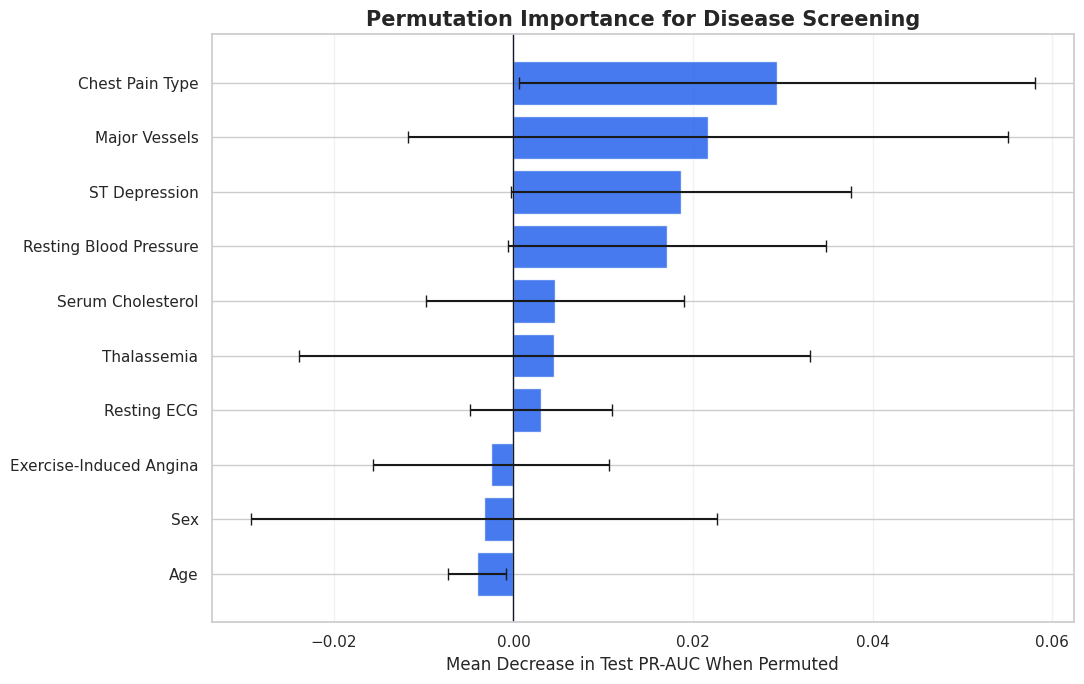

In [8]:
# ============================================================
# PERMUTATION FEATURE IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Importance": permutation_results.importances_mean,
    "Importance SD": permutation_results.importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Mean Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_display_names = {
    "age": "Age",
    "sex": "Sex",
    "chest_pain_type": "Chest Pain Type",
    "resting_blood_pressure": "Resting Blood Pressure",
    "serum_cholesterol": "Serum Cholesterol",
    "fasting_blood_sugar": "Fasting Blood Sugar",
    "resting_ecg": "Resting ECG",
    "maximum_heart_rate": "Maximum Heart Rate",
    "exercise_induced_angina": "Exercise-Induced Angina",
    "st_depression": "ST Depression",
    "st_slope": "ST Segment Slope",
    "major_vessels": "Major Vessels",
    "thalassemia": "Thalassemia"
}

feature_importance_df["Display Feature"] = (
    feature_importance_df["Feature"]
    .map(feature_display_names)
)

print("=" * 72)
print("PERMUTATION IMPORTANCE USING TEST PR-AUC")
print("=" * 72)

display(
    feature_importance_df[
        [
            "Display Feature",
            "Mean Importance",
            "Importance SD"
        ]
    ].style.format({
        "Mean Importance": "{:.4f}",
        "Importance SD": "{:.4f}"
    })
)

# Plot the ten most influential features.
top_feature_importance = (
    feature_importance_df
    .head(10)
    .sort_values(
        by="Mean Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_feature_importance["Display Feature"],
    top_feature_importance["Mean Importance"],
    xerr=top_feature_importance["Importance SD"],
    color="#2563EB",
    alpha=0.85,
    capsize=4
)

plt.axvline(
    0,
    color="#111827",
    linewidth=1
)

plt.title(
    "Permutation Importance for Disease Screening",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Mean Decrease in Test PR-AUC When Permuted")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Interactive Screening Demonstration

This interface allows users to enter a hypothetical patient profile and view the model’s estimated probability and screening route.

The default 0.50 threshold is retained because the lower cost-sensitive threshold did not reduce false negatives on the held-out test set and generated additional false positives.

The output is an analytical demonstration only. It is not a diagnosis, medical recommendation, or validated clinical decision.

In [9]:
# ============================================================
# INTERACTIVE HEART-DISEASE SCREENING DEMONSTRATION
# ============================================================

import ipywidgets as widgets

from IPython.display import (
    display,
    clear_output,
    Markdown
)

# ============================================================
# 1. CREATE INPUT WIDGETS
# ============================================================

age_widget = widgets.IntSlider(
    value=55,
    min=25,
    max=80,
    step=1,
    description="Age:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

sex_widget = widgets.Dropdown(
    options=[
        ("Female", 0),
        ("Male", 1)
    ],
    value=1,
    description="Sex:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

chest_pain_widget = widgets.Dropdown(
    options=[
        ("Typical angina", 1),
        ("Atypical angina", 2),
        ("Non-anginal pain", 3),
        ("Asymptomatic", 4)
    ],
    value=4,
    description="Chest pain type:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

resting_bp_widget = widgets.IntSlider(
    value=130,
    min=90,
    max=200,
    step=1,
    description="Resting blood pressure:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

cholesterol_widget = widgets.IntSlider(
    value=220,
    min=120,
    max=570,
    step=1,
    description="Serum cholesterol:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

fasting_blood_sugar_widget = widgets.Dropdown(
    options=[
        ("Not above 120 mg/dL", 0),
        ("Above 120 mg/dL", 1)
    ],
    value=0,
    description="Fasting blood sugar:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

resting_ecg_widget = widgets.Dropdown(
    options=[
        ("Normal", 0),
        ("ST-T wave abnormality", 1),
        ("Left ventricular hypertrophy", 2)
    ],
    value=0,
    description="Resting ECG:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

maximum_heart_rate_widget = widgets.IntSlider(
    value=150,
    min=70,
    max=210,
    step=1,
    description="Maximum heart rate:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

exercise_angina_widget = widgets.Dropdown(
    options=[
        ("No", 0),
        ("Yes", 1)
    ],
    value=0,
    description="Exercise-induced angina:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

st_depression_widget = widgets.FloatSlider(
    value=1.0,
    min=0.0,
    max=6.5,
    step=0.1,
    description="ST depression:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

st_slope_widget = widgets.Dropdown(
    options=[
        ("Upsloping", 1),
        ("Flat", 2),
        ("Downsloping", 3)
    ],
    value=2,
    description="ST segment slope:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

major_vessels_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=3,
    step=1,
    description="Major vessels:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

thalassemia_widget = widgets.Dropdown(
    options=[
        ("Normal", 3),
        ("Fixed defect", 6),
        ("Reversible defect", 7)
    ],
    value=3,
    description="Thalassemia:",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="600px")
)

screen_button = widgets.Button(
    description="Evaluate Screening Profile",
    button_style="primary",
    icon="search",
    layout=widgets.Layout(
        width="260px",
        height="42px"
    )
)

screening_output = widgets.Output()

# ============================================================
# 2. DEFINE THE SCREENING FUNCTION
# ============================================================

def evaluate_screening_profile(button_click):

    patient_profile = pd.DataFrame({
        "age": [
            age_widget.value
        ],
        "sex": [
            sex_widget.value
        ],
        "chest_pain_type": [
            chest_pain_widget.value
        ],
        "resting_blood_pressure": [
            resting_bp_widget.value
        ],
        "serum_cholesterol": [
            cholesterol_widget.value
        ],
        "fasting_blood_sugar": [
            fasting_blood_sugar_widget.value
        ],
        "resting_ecg": [
            resting_ecg_widget.value
        ],
        "maximum_heart_rate": [
            maximum_heart_rate_widget.value
        ],
        "exercise_induced_angina": [
            exercise_angina_widget.value
        ],
        "st_depression": [
            st_depression_widget.value
        ],
        "st_slope": [
            st_slope_widget.value
        ],
        "major_vessels": [
            major_vessels_widget.value
        ],
        "thalassemia": [
            thalassemia_widget.value
        ]
    })

    estimated_probability = (
        final_model.predict_proba(
            patient_profile
        )[0, 1]
    )

    if estimated_probability >= 0.50:
        screening_route = (
            "Flag for further professional assessment"
        )
        route_color = "#B91C1C"
    else:
        screening_route = (
            "No automated escalation at the demonstrated threshold"
        )
        route_color = "#166534"

    with screening_output:

        clear_output(wait=True)

        display(
            Markdown(
                f"""
### Screening Demonstration Result

**Estimated model probability:**
<span style="font-size:24px; color:{route_color};">
{estimated_probability:.1%}
</span>

**Demonstrated screening route:**
**{screening_route}**

**Decision threshold:** 50%

> This output is an educational model demonstration. It is not a diagnosis, medical advice, or a validated clinical decision.
                """
            )
        )

# Connect the button to the function.
screen_button.on_click(
    evaluate_screening_profile
)

# ============================================================
# 3. DISPLAY THE INTERFACE
# ============================================================

display(
    Markdown(
        "### Hypothetical Patient Inputs"
    )
)

display(
    age_widget,
    sex_widget,
    chest_pain_widget,
    resting_bp_widget,
    cholesterol_widget,
    fasting_blood_sugar_widget,
    resting_ecg_widget,
    maximum_heart_rate_widget,
    exercise_angina_widget,
    st_depression_widget,
    st_slope_widget,
    major_vessels_widget,
    thalassemia_widget,
    screen_button,
    screening_output
)

### Hypothetical Patient Inputs

IntSlider(value=55, description='Age:', layout=Layout(width='600px'), max=80, min=25, style=SliderStyle(descri…

Dropdown(description='Sex:', index=1, layout=Layout(width='600px'), options=(('Female', 0), ('Male', 1)), styl…

Dropdown(description='Chest pain type:', index=3, layout=Layout(width='600px'), options=(('Typical angina', 1)…

IntSlider(value=130, description='Resting blood pressure:', layout=Layout(width='600px'), max=200, min=90, sty…

...

Dropdown(description='ST segment slope:', index=1, layout=Layout(width='600px'), options=(('Upsloping', 1), ('…

IntSlider(value=0, description='Major vessels:', layout=Layout(width='600px'), max=3, style=SliderStyle(descri…

Dropdown(description='Thalassemia:', layout=Layout(width='600px'), options=(('Normal', 3), ('Fixed defect', 6)…

Button(button_style='primary', description='Evaluate Screening Profile', icon='search', layout=Layout(height='…

Output()

## Final Conclusions and Recommendations

This project developed a leakage-safe, cost-sensitive heart-disease screening workflow using the UCI Statlog Heart dataset. Logistic Regression was selected because it provided the strongest overall balance of predictive performance, probability calibration, interpretability, and screening recall during repeated cross-validation.

### Final Held-Out Test Performance

At the default 0.50 decision threshold, the selected model achieved:

- **Accuracy:** 87.0%
- **Balanced accuracy:** 87.5%
- **Precision:** 81.5%
- **Recall:** 91.7%
- **F1 score:** 86.3%
- **ROC-AUC:** 90.8%
- **PR-AUC:** 86.6%
- **Brier score:** 0.114
- **False positives:** 5
- **False negatives:** 2
- **Total relative cost:** 15

These results indicate strong ranking performance and high sensitivity on the held-out test set. However, the test sample contained only 54 observations, and the bootstrap confidence intervals remained relatively wide. The results should therefore be interpreted as preliminary rather than clinically definitive.

### Threshold-Optimization Finding

A cost-sensitive threshold of 0.36 reduced development-set relative cost from 134 to 79 and improved recall during threshold selection. However, this improvement did not generalize to the held-out test set.

On the test set, both thresholds identified 22 of the 24 positive cases. The 0.36 threshold produced two additional false positives without reducing false negatives, increasing relative cost from 15 to 17.

This demonstrates an important model-risk lesson: a threshold optimized on development data may overfit and should not be adopted solely because it performs well during model development.

### Recommendation

The 0.36 cost-sensitive threshold is **not recommended for operational use** based on the held-out results. The default 0.50 threshold performed better in this test comparison, but it should also undergo external and prospective validation before being considered for any real-world application.

Future work should include:

1. Validation using a larger and more representative dataset.
2. Testing across different demographic and clinical populations.
3. Fairness and subgroup-performance analysis.
4. Prospective evaluation of threshold costs.
5. Review of cost assumptions with qualified clinical stakeholders.
6. Monitoring for calibration drift and changes in data quality.

### Responsible-Use Statement

This project is an educational machine-learning and decision-support demonstration. It is not a medical device, diagnostic system, or substitute for evaluation by a qualified healthcare professional. Model probabilities and screening routes must not be interpreted as clinical diagnoses or treatment recommendations.


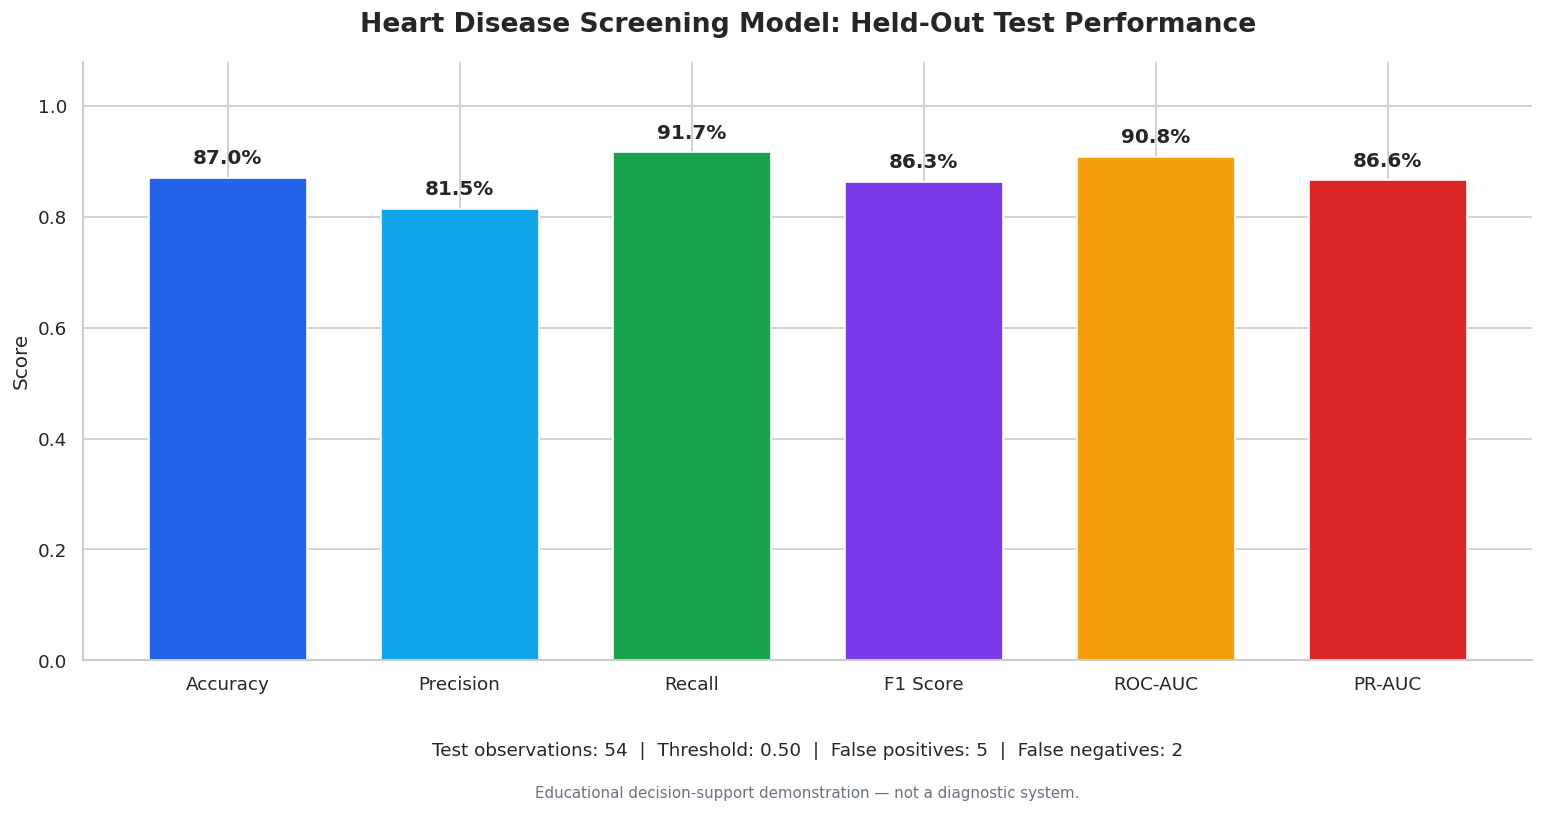

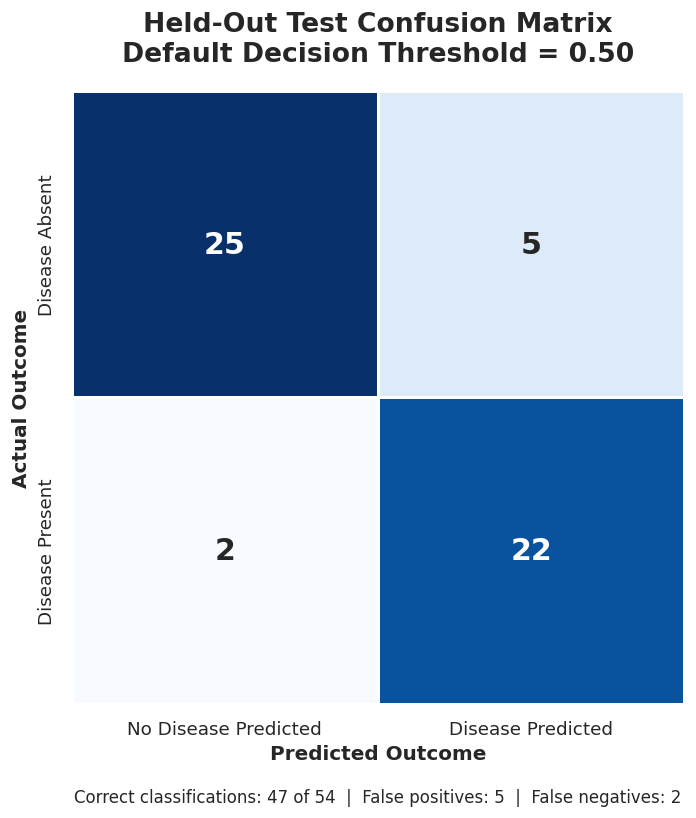

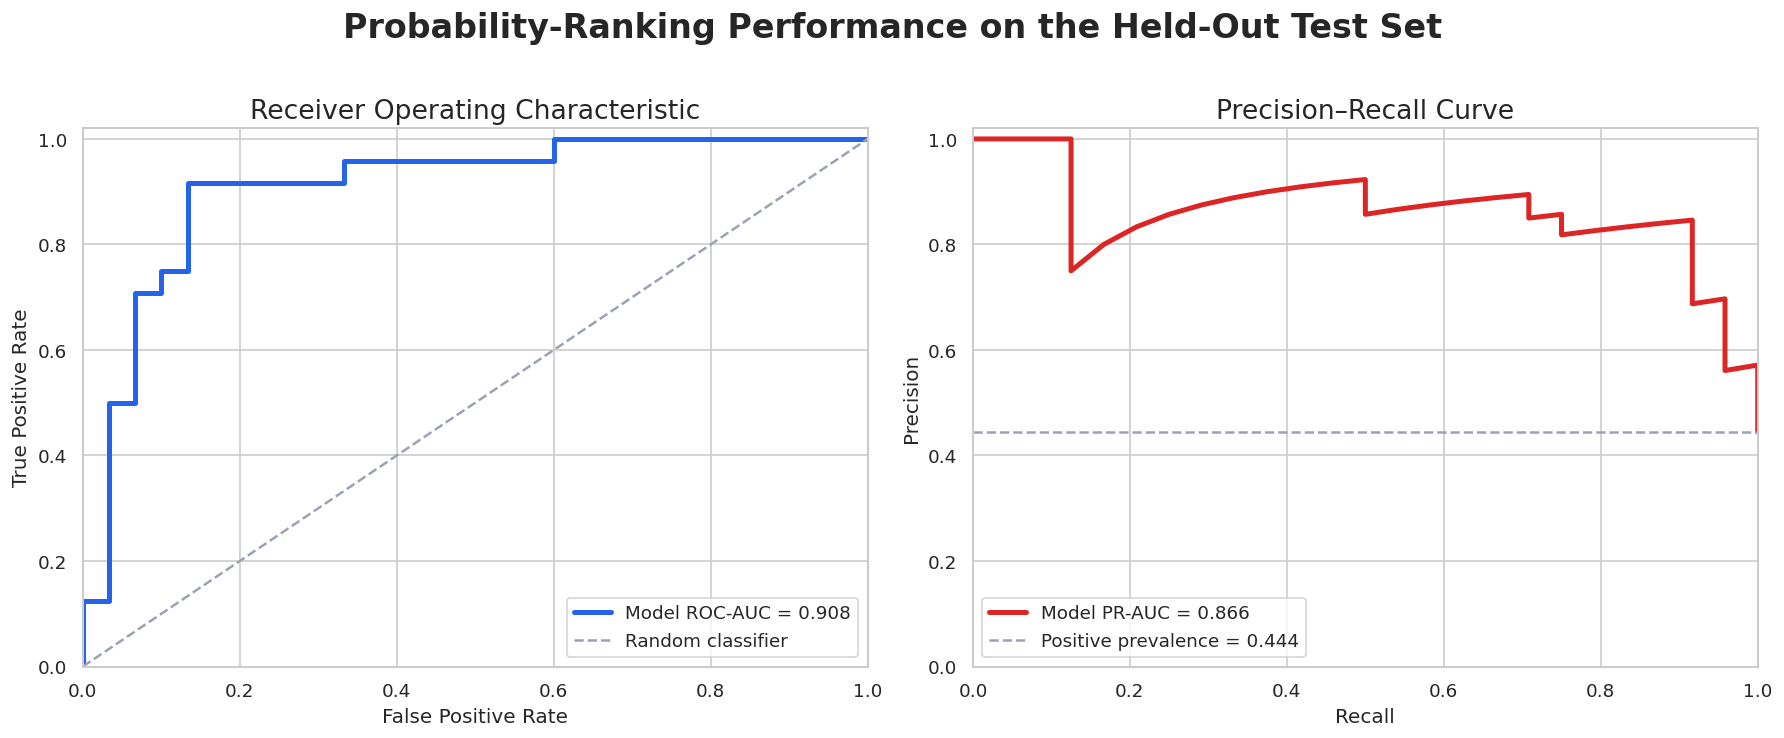

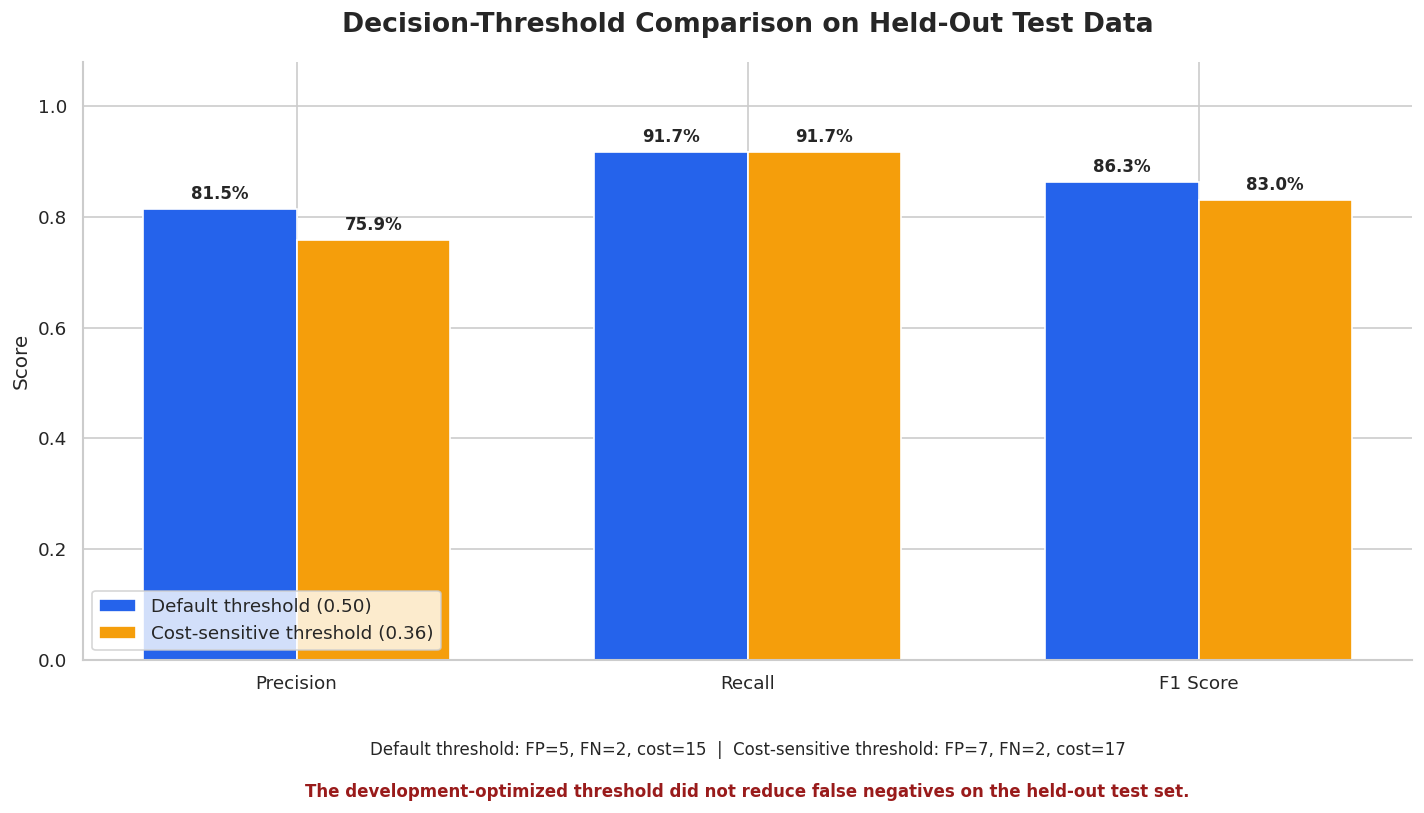

,Decision Rule,Threshold,Accuracy,Precision,Recall,Specificity,F1 Score,False Positives,False Negatives,Relative Cost
0,Default Threshold,0.5000,0.8700,0.8150,0.9170,0.8330,0.8630,5,2,15
1,Cost-Sensitive Threshold,0.3600,0.8330,0.7590,0.9170,0.7670,0.8300,7,2,17


PORTFOLIO VISUALS CREATED SUCCESSFULLY
held-out-test-performance.png
roc-pr-curves.png
test-confusion-matrix.png
threshold-comparison.png

ZIP file: /content/heart-disease-screening-portfolio-visuals.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ============================================================
# HIGH-RESOLUTION PORTFOLIO VISUALS
# Cost-Sensitive Heart Disease Screening
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Output settings
# ------------------------------------------------------------

OUTPUT_DIR = "/content/heart_screening_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "figure.titlesize": 20
})

DEFAULT_THRESHOLD = 0.50
COST_THRESHOLD = 0.36

# Recalculate test probabilities from the fitted final model
test_probabilities = final_model.predict_proba(X_test)[:, 1]

default_predictions = (
    test_probabilities >= DEFAULT_THRESHOLD
).astype(int)

cost_predictions = (
    test_probabilities >= COST_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def calculate_results(y_true, predictions, threshold):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0
    relative_cost = fp + (5 * fn)

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1 Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "False Positives": fp,
        "False Negatives": fn,
        "Relative Cost": relative_cost
    }


default_results = calculate_results(
    y_test,
    default_predictions,
    DEFAULT_THRESHOLD
)

cost_results = calculate_results(
    y_test,
    cost_predictions,
    COST_THRESHOLD
)

comparison_df = pd.DataFrame([
    {
        "Decision Rule": "Default Threshold",
        **default_results
    },
    {
        "Decision Rule": "Cost-Sensitive Threshold",
        **cost_results
    }
])

roc_auc = roc_auc_score(y_test, test_probabilities)
pr_auc = average_precision_score(y_test, test_probabilities)

# ------------------------------------------------------------
# VISUAL 1: Executive model-performance summary
# ------------------------------------------------------------

summary_metrics = {
    "Accuracy": default_results["Accuracy"],
    "Precision": default_results["Precision"],
    "Recall": default_results["Recall"],
    "F1 Score": default_results["F1 Score"],
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

metric_names = list(summary_metrics.keys())
metric_values = list(summary_metrics.values())

fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    "#2563EB",
    "#0EA5E9",
    "#16A34A",
    "#7C3AED",
    "#F59E0B",
    "#DC2626"
]

bars = ax.bar(
    metric_names,
    metric_values,
    color=colors,
    width=0.68
)

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.018,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title(
    "Heart Disease Screening Model: Held-Out Test Performance",
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    -0.16,
    (
        f"Test observations: {len(y_test)}  |  "
        f"Threshold: {DEFAULT_THRESHOLD:.2f}  |  "
        f"False positives: {default_results['False Positives']}  |  "
        f"False negatives: {default_results['False Negatives']}"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.text(
    0.5,
    -0.23,
    "Educational decision-support demonstration — not a diagnostic system.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color="#6B7280"
)

sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "held-out-test-performance.png"),
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ------------------------------------------------------------
# VISUAL 2: Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    default_predictions,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    square=True,
    xticklabels=[
        "No Disease Predicted",
        "Disease Predicted"
    ],
    yticklabels=[
        "Disease Absent",
        "Disease Present"
    ],
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_xlabel("Predicted Outcome", fontweight="bold")
ax.set_ylabel("Actual Outcome", fontweight="bold")
ax.set_title(
    "Held-Out Test Confusion Matrix\nDefault Decision Threshold = 0.50",
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    -0.16,
    (
        f"Correct classifications: {int(cm[0,0] + cm[1,1])} of "
        f"{int(cm.sum())}  |  False positives: {int(cm[0,1])}  |  "
        f"False negatives: {int(cm[1,0])}"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "test-confusion-matrix.png"),
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ------------------------------------------------------------
# VISUAL 3: ROC and precision-recall curves
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, test_probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

positive_prevalence = np.mean(y_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curve
axes[0].plot(
    fpr,
    tpr,
    color="#2563EB",
    linewidth=3,
    label=f"Model ROC-AUC = {roc_auc:.3f}"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#9CA3AF",
    label="Random classifier"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Receiver Operating Characteristic")
axes[0].legend(loc="lower right")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)

# Precision-recall curve
axes[1].plot(
    recall_curve,
    precision_curve,
    color="#DC2626",
    linewidth=3,
    label=f"Model PR-AUC = {pr_auc:.3f}"
)

axes[1].axhline(
    positive_prevalence,
    linestyle="--",
    color="#9CA3AF",
    label=f"Positive prevalence = {positive_prevalence:.3f}"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend(loc="lower left")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

fig.suptitle(
    "Probability-Ranking Performance on the Held-Out Test Set",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "roc-pr-curves.png"),
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ------------------------------------------------------------
# VISUAL 4: Threshold comparison
# ------------------------------------------------------------

comparison_metrics = [
    "Precision",
    "Recall",
    "F1 Score"
]

default_metric_values = [
    default_results[metric]
    for metric in comparison_metrics
]

cost_metric_values = [
    cost_results[metric]
    for metric in comparison_metrics
]

x = np.arange(len(comparison_metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 7))

bars_default = ax.bar(
    x - width / 2,
    default_metric_values,
    width,
    label="Default threshold (0.50)",
    color="#2563EB"
)

bars_cost = ax.bar(
    x + width / 2,
    cost_metric_values,
    width,
    label="Cost-sensitive threshold (0.36)",
    color="#F59E0B"
)

for bars in [bars_default, bars_cost]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.018,
            f"{value:.1%}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(comparison_metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title(
    "Decision-Threshold Comparison on Held-Out Test Data",
    fontweight="bold",
    pad=18
)
ax.legend(loc="lower left")

ax.text(
    0.5,
    -0.16,
    (
        f"Default threshold: FP={default_results['False Positives']}, "
        f"FN={default_results['False Negatives']}, "
        f"cost={default_results['Relative Cost']}  |  "
        f"Cost-sensitive threshold: FP={cost_results['False Positives']}, "
        f"FN={cost_results['False Negatives']}, "
        f"cost={cost_results['Relative Cost']}"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.text(
    0.5,
    -0.23,
    (
        "The development-optimized threshold did not reduce false negatives "
        "on the held-out test set."
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#991B1B",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "threshold-comparison.png"),
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ------------------------------------------------------------
# 3. Display comparison table
# ------------------------------------------------------------

display_columns = [
    "Decision Rule",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score",
    "False Positives",
    "False Negatives",
    "Relative Cost"
]

display(
    comparison_df[display_columns].round(3)
)

# ------------------------------------------------------------
# 4. Create one ZIP file and download it
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    "/content/heart-disease-screening-portfolio-visuals",
    "zip",
    OUTPUT_DIR
)

print("=" * 70)
print("PORTFOLIO VISUALS CREATED SUCCESSFULLY")
print("=" * 70)

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

print(f"\nZIP file: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Automatic download was unavailable.")
    print("Download the ZIP manually from the Colab Files panel.")

In [21]:
from google.colab import files
files.download("/content/heart-disease-screening-portfolio-visuals.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>